In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')
# Path to your subfolder containing the data
folder_path = '/content/drive/MyDrive/prakpola/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
dataset_path = folder_path + '/breast_cancer_wisconsin_data.csv' # Assuming you want an empty string here, adjust if needed
#membaca dataset
data = pd.read_csv(dataset_path)
print(data)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

In [ ]:
#menghapus data kolom yang tidak digunakan
data.drop(["Unnamed: 32","id"], axis=1, inplace=True)
#merubah label M(Ganas)=1 dan B(Jinak)=0
data.diagnosis=[1 if each=="M" else 0 for each in data.diagnosis]
#menampilkan sample data
data.head(3)
#Menentukan nilai X dan Y
kolom = data.columns.to_list()
x = data[kolom[1:30]]
y = data[kolom[0]]
print(x,y)
#Membagi data menjadi dua yaitu data testing dan data training
from sklearn.model_selection import train_test_split
x_train, _test, y_train, _test = train_test_split(x,y,test_size=0.25,random_state=42)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  sym

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42) # Changed _test to x_test and y_test
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
#Menentukan tujuan prediksi pada x_test
y_pred = model.predict(x_test)
print(y_pred)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 1 0 1 0]


In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[85,  4],
       [ 3, 51]])

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[85,  4],
       [ 3, 51]])

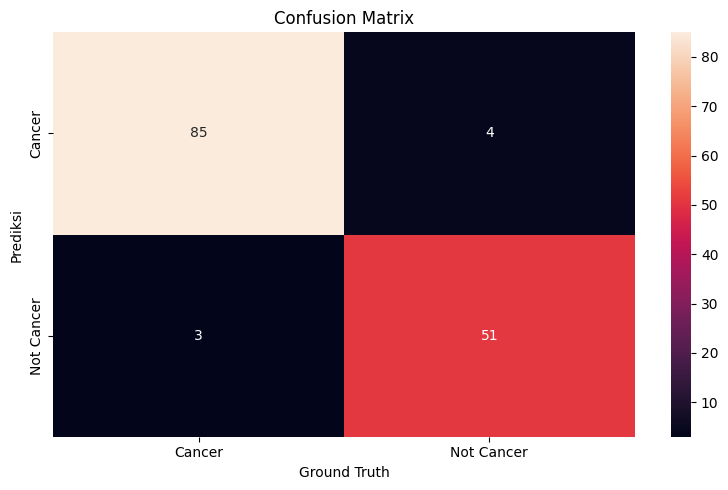

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasikan confusion matrix
f,ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True,
fmt=".0f", ax=ax)
tick_marks = np.arange(2)+0.5
plt.xticks(tick_marks, ['Cancer', 'Not Cancer'])
plt.yticks(tick_marks, ['Cancer', 'Not Cancer'])
# Tambahkan teks pada sel confusion matrix
plt.title('Confusion Matrix')
plt.ylabel('Prediksi')
plt.xlabel('Ground Truth')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Definisikan nilai True Positive (TP), True Negative (TN), False Positive (FP),   False Negative (FN)
TP = 82 # Jumlah Ibu hamil yang terdeteksi benar hamil
TN = 7 # Jumlah Ibu tidak hamil yang terdeteksi benar tidak hamil
FP = 3 # Jumlah Ibu tidak hamil yang salah terdeteksi hamil
FN = 51 # Jumlah Ibu hamil yang salah terdeteksi tidak hamil

In [ ]:
# Hitung metrik evaluasi menggunakan confusion matrix
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
# Tampilkan hasil metrik evaluasi
print("Hasil metrik evaluasi:")
print(f"Akurasi: {accuracy:.2f}")
print(f"Presisi: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1_score:.2f}")

Hasil metrik evaluasi:
Akurasi: 0.62
Presisi: 0.96
Recall: 0.62
F1-score: 0.75


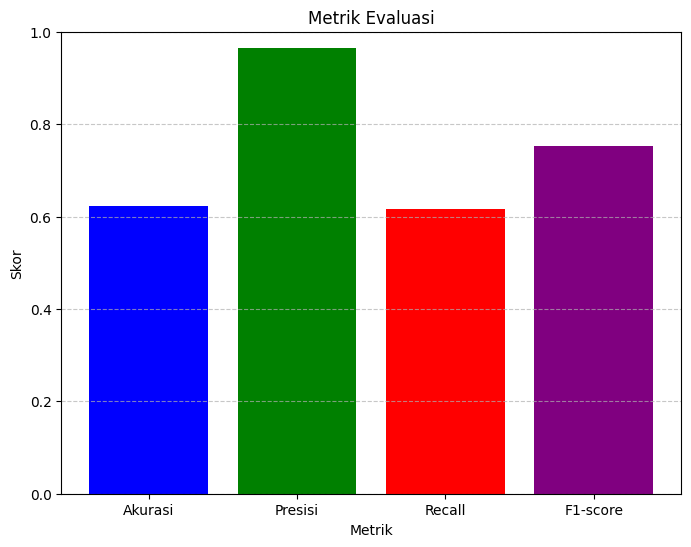

In [ ]:
# Definisikan metrik evaluasi
metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-score']
scores = [accuracy, precision, recall, f1_score]
# Visualisasikan metrik evaluasi dalam bentuk bar chart
plt.figure(figsize=(8, 6))
plt.bar(metrics, scores, color=['blue', 'green', 'red', 'purple'])
plt.title('Metrik Evaluasi')
plt.xlabel('Metrik')
plt.ylabel('Skor')
plt.ylim(0, 1) # Set batas sumbu y antara 0 dan 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

POSTEST

In [ ]:
# Definisikan nilai True Positive (TP), True Negative (TN), False Positive (FP),   False Negative (FN)
TP = 30 # Jumlah email spam yang terdeteksi benar spam
TN = 50 # Jumlah email spam tidak spam yang terdeteksi benar tidak spam
FP = 10 # Jumlah email tidak tidak spam yang salah terdeteksi spam
FN = 10 # Jumlah email spam yang salah terdeteksi tidak spam

In [ ]:
# Hitung metrik evaluasi menggunakan confusion matrix
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
# Tampilkan hasil metrik evaluasi
print("Hasil metrik evaluasi:")
print(f"Akurasi: {accuracy:.2f}")
print(f"Presisi: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1_score:.2f}")

Hasil metrik evaluasi:
Akurasi: 0.80
Presisi: 0.75
Recall: 0.75
F1-score: 0.75


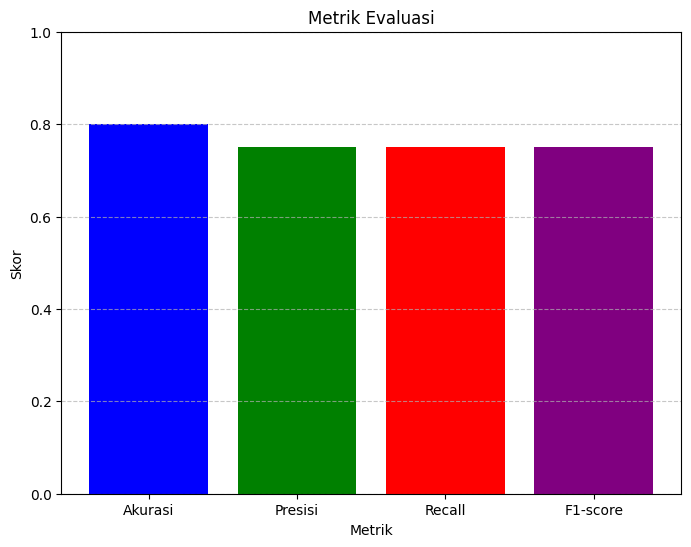

In [ ]:
# Definisikan metrik evaluasi
metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-score']
scores = [accuracy, precision, recall, f1_score]
# Visualisasikan metrik evaluasi dalam bentuk bar chart
plt.figure(figsize=(8, 6))
plt.bar(metrics, scores, color=['blue', 'green', 'red', 'purple'])
plt.title('Metrik Evaluasi')
plt.xlabel('Metrik')
plt.ylabel('Skor')
plt.ylim(0, 1) # Set batas sumbu y antara 0 dan 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()